In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [3]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

In [4]:
train_data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    download = True,
    transform = ToTensor()
)

In [5]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [6]:
image.shape

torch.Size([1, 28, 28])

In [7]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [8]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Image Shape = torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

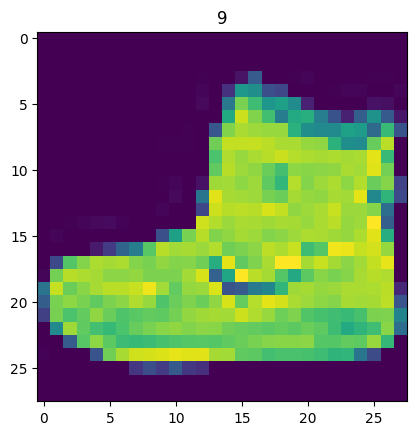

In [9]:
image, label = train_data[0]
print(f'Image Shape = {image.shape}')
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

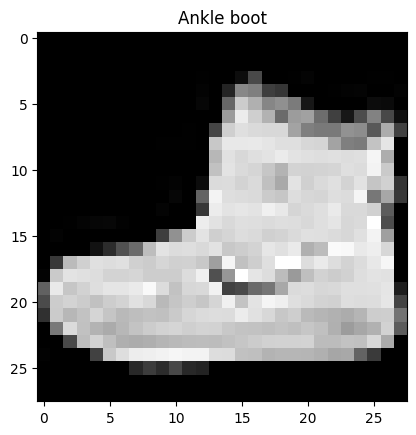

In [10]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(train_data.classes[label])

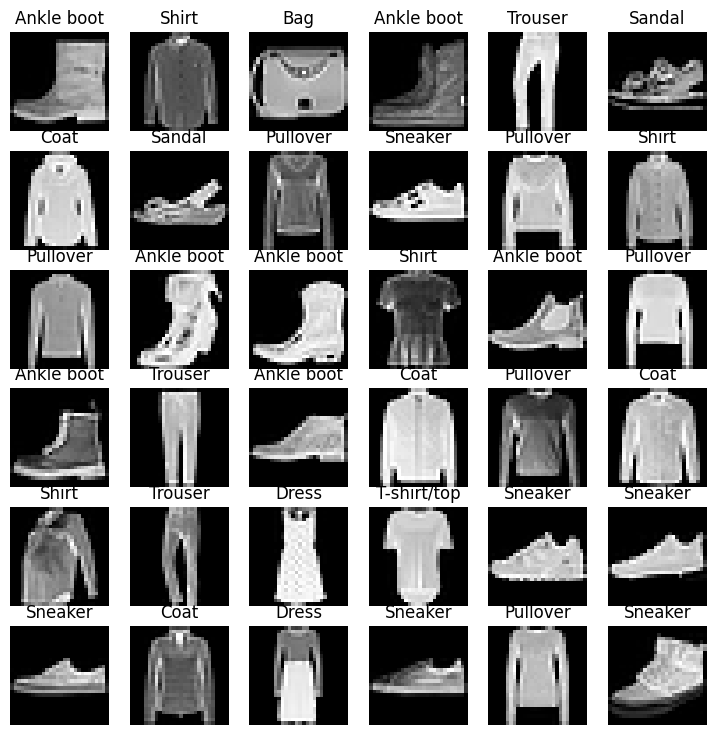

In [11]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 6,6
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size = [1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(),cmap = 'gray')
    plt.title(train_data.classes[label])
    plt.axis(False)


In [12]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                               batch_size = BATCH_SIZE,
                               shuffle = True)

test_dataloader = DataLoader(test_data,
                              batch_size = BATCH_SIZE,
                              shuffle = False)

train_dataloader, test_dataloader, len(train_dataloader), len(test_dataloader)

(<torch.utils.data.dataloader.DataLoader at 0x1f82a87b140>,
 1875,
 313)

In [13]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [14]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)
x.shape, output.shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]))

In [15]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_features: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features = hidden_features),
            nn.Linear(in_features = hidden_features, out_features = output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)
        
        

In [16]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784, 
    hidden_features=10, 
    output_shape=len(train_data.classes) 
)

In [17]:
import requests
from pathlib import Path 

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [18]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [19]:
from timeit import default_timer as timer
def print_train_time(start : float, end : float, device: torch.device = None):
    total_time = end - start
    print(total_time)
    return total_time

In [20]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 2

for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}\n----------')
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
        train_loss /= len(train_dataloader)

        test_loss, test_acc = 0,0
        model_0.eval()
        with torch.inference_mode():
            for X, y in test_dataloader:
                test_pred = model_0(X)
                test_loss += loss_fn(test_pred, y) 
                test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
            test_loss /= len(test_dataloader)
            test_acc /= len(test_dataloader)
        print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")    
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))




c:\Users\prave\anaconda3\envs\torch-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/2 [00:00<?, ?it/s]

Epoch: 0
----------
Looked at 0/60000 samples

Train loss: 0.00126 | Test loss: 2.32090, Test acc: 15.12%


Train loss: 0.00123 | Test loss: 2.26242, Test acc: 11.68%


Train loss: 0.00120 | Test loss: 2.22764, Test acc: 18.13%


Train loss: 0.00120 | Test loss: 2.19694, Test acc: 10.47%


Train loss: 0.00118 | Test loss: 2.14442, Test acc: 26.31%


Train loss: 0.00117 | Test loss: 2.09453, Test acc: 30.25%


Train loss: 0.00113 | Test loss: 2.05269, Test acc: 29.83%


Train loss: 0.00108 | Test loss: 2.09163, Test acc: 19.04%


Train loss: 0.00111 | Test loss: 2.00115, Test acc: 35.41%


Train loss: 0.00104 | Test loss: 1.95626, Test acc: 42.24%


Train loss: 0.00104 | Test loss: 1.90095, Test acc: 40.51%


Train loss: 0.00102 | Test loss: 1.88389, Test acc: 40.92%


Train loss: 0.00100 | Test loss: 1.84417, Test acc: 42.53%


Train loss: 0.00103 | Test loss: 1.78902, Test acc: 43.65%


Train loss: 0.00097 | Test loss: 1.81196, Test acc: 42.25%


Train loss: 0.00098 | Test loss: 1.717

 50%|█████     | 1/2 [42:26<42:26, 2546.52s/it]


Train loss: 0.00025 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
----------
Looked at 0/60000 samples

Train loss: 0.00025 | Test loss: 0.51210, Test acc: 82.29%


Train loss: 0.00024 | Test loss: 0.51866, Test acc: 81.53%


Train loss: 0.00014 | Test loss: 0.50547, Test acc: 82.39%


Train loss: 0.00027 | Test loss: 0.50543, Test acc: 82.54%


Train loss: 0.00030 | Test loss: 0.53538, Test acc: 81.07%


Train loss: 0.00027 | Test loss: 0.62581, Test acc: 77.64%


Train loss: 0.00034 | Test loss: 0.53409, Test acc: 80.79%


Train loss: 0.00028 | Test loss: 0.60799, Test acc: 76.89%


Train loss: 0.00028 | Test loss: 0.54236, Test acc: 80.84%


Train loss: 0.00034 | Test loss: 0.55731, Test acc: 80.96%


Train loss: 0.00029 | Test loss: 0.54780, Test acc: 80.55%


Train loss: 0.00016 | Test loss: 0.49695, Test acc: 82.54%


Train loss: 0.00017 | Test loss: 0.50751, Test acc: 82.29%


Train loss: 0.00030 | Test loss: 0.51301, Test acc: 82.04%


Train loss: 0.00031 | Test loss: 0.531

100%|██████████| 2/2 [1:13:58<00:00, 2219.41s/it]


Train loss: 0.00028 | Test loss: 0.47997, Test acc: 83.49%

4438.863351799999


In [21]:
torch.save(model_0.state_dict(), 'model_0.pth')

In [22]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model_0(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true = y,
                               y_pred = y_pred.argmax(dim = 1))
            
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4799667298793793,
 'model_acc': 83.48642172523962}

In [24]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )
    
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [27]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, 
    hidden_units=10,
    output_shape=len(train_data.classes)) 
next(model_1.parameters())

Parameter containing:
tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
        [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
        [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
        ...,
        [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
        [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
        [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]],
       requires_grad=True)

In [28]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), 
                            lr=0.1)